### Krisha Shetty 
#### DS219
#### Online shoppers purchasing intentions

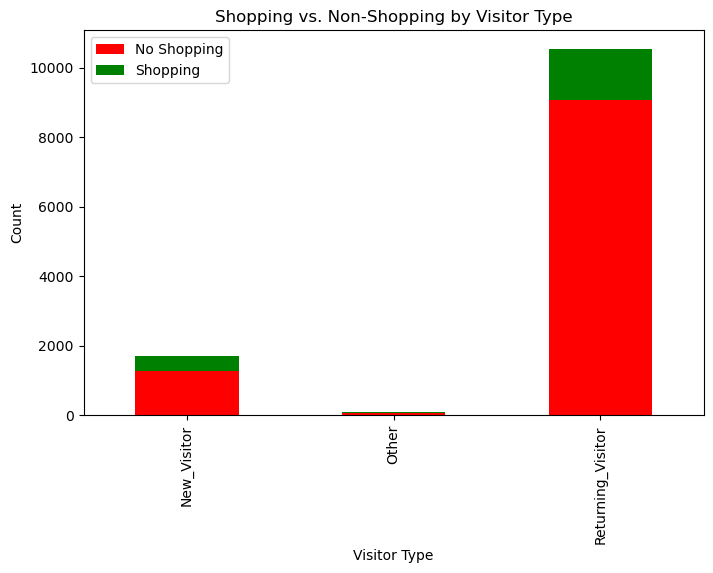

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('online_shoppers_intention.csv')
df.head()
df["Revenue"] = df["Revenue"].astype(bool)
revenue_counts = df["Revenue"].value_counts()
# stacked bar chart
visitor_counts = df.groupby(["VisitorType", "Revenue"]).size().unstack()
visitor_counts.plot(kind="bar", stacked=True, color=["red", "green"], figsize=(8,5))
plt.xlabel("Visitor Type")
plt.ylabel("Count")
plt.title("Shopping vs. Non-Shopping by Visitor Type")
plt.legend(["No Shopping", "Shopping"])
plt.show()

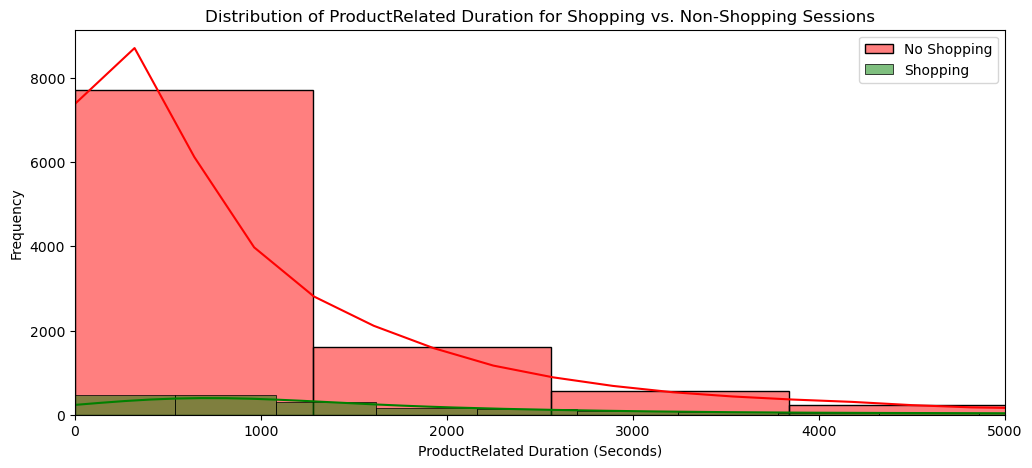

In [40]:
# Plot distributions
plt.figure(figsize=(12,5))
sns.histplot(df[df["Revenue"] == False]["ProductRelated_Duration"], bins=50, color='red', label="No Shopping", kde=True)
sns.histplot(df[df["Revenue"] == True]["ProductRelated_Duration"], bins=50, color='green', label="Shopping", kde=True)
plt.legend()
plt.xlabel("ProductRelated Duration (Seconds)")
plt.ylabel("Frequency")
plt.title("Distribution of ProductRelated Duration for Shopping vs. Non-Shopping Sessions")
plt.xlim(0, 5000) 
plt.show()



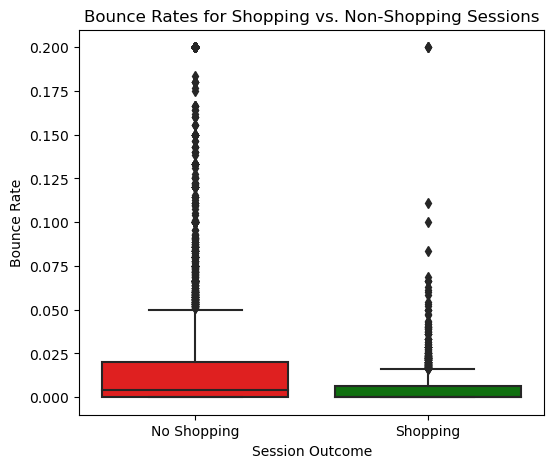

In [32]:
# Boxplot with BounceRates 
plt.figure(figsize=(6,5))
sns.boxplot(x="Revenue", y="BounceRates", data=df, palette=["red", "green"])
plt.xticks([0, 1], ["No Shopping", "Shopping"])
plt.xlabel("Session Outcome")
plt.ylabel("Bounce Rate")
plt.title("Bounce Rates for Shopping vs. Non-Shopping Sessions")
plt.show()



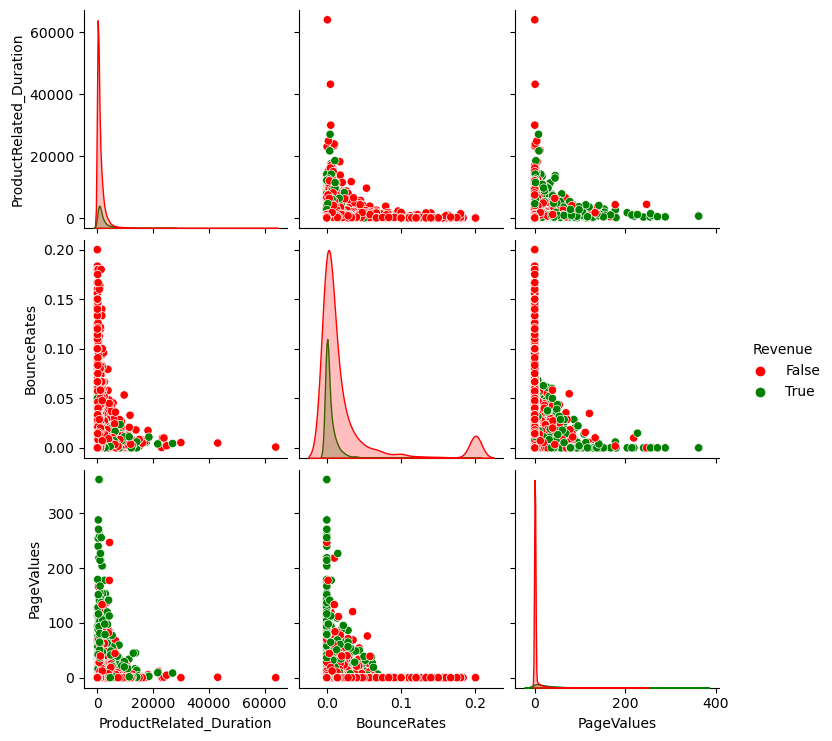

In [34]:
# Pairplot with numeric features
sns.pairplot(df, hue="Revenue", vars=["ProductRelated_Duration", "BounceRates", "PageValues"], palette=["red", "green"])
plt.show()

## Hypothesis testing

### Hypothesis 1

**Hypothesis formulation 1:**
Based on the charts above, the following hypothesis is as stated that users who shop tend to have longer session durations than those who don’t

In [41]:
from scipy.stats import ttest_ind, chi2_contingency, pearsonr
shopping_sessions = df[df["Revenue"] == True]["ProductRelated_Duration"]
non_shopping_sessions = df[df["Revenue"] == False]["ProductRelated_Duration"]

t_stat, p_value = ttest_ind(shopping_sessions, non_shopping_sessions, equal_var=False)

print(f"Hypothesis 1 - Session Duration & Shopping")
print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")

Hypothesis 1 - Session Duration & Shopping
T-statistic: 14.4470, P-value: 0.0000


### Hypothesis 2

**Hypothesis formulation 2:**
Based on the charts above, the following hypothesis is as stated that shopping sessions have lower bounce rates compared to non-shopping sessions

In [44]:
shopping_bounce = df[df["Revenue"] == True]["BounceRates"]
non_shopping_bounce = df[df["Revenue"] == False]["BounceRates"]

t_stat2, p_value2 = ttest_ind(shopping_bounce, non_shopping_bounce, equal_var=False)

print(f"\nHypothesis 2 - Bounce Rate & Shopping")
print(f"T-statistic: {t_stat2:.4f}, P-value: {p_value2:.4f}")



Hypothesis 2 - Bounce Rate & Shopping
T-statistic: -34.8464, P-value: 0.0000


### Results

**Hypothesis 1:**

Null Hypothesis (H₀):
There is no relationship between session duration (ProductRelated_Duration) and the likelihood of shopping.

The violin correlation coefficient ρ = 0.

The average session duration for users who shop is equal to the average session duration for users who do not shop.

Alternative Hypothesis (H₁):
There is a positive relationship between session duration and shopping likelihood.

The violin correlation coefficient ρ > 0.

The average session duration for users who shop is higher than the average session duration for users who do not shop.

**Hypothesis 2:**

Null Hypothesis (H₀):
There is no relationship between BounceRates and the likelihood of shopping.

The graph correlation coefficient ρ = 0.

The average bounce rate for shopping sessions is equal to the average bounce rate for non-shopping sessions.

Alternative Hypothesis (H₁):
There is a negative relationship between BounceRates and shopping likeliehood.

The graph correlation coefficient ρ < 0.

The average bounce rate for shopping sessions is lower than the average bounce rate for non-shopping sessions.



### Conclusions
**Hypothesis 1:**

Based on the results of the violin correlation and T-test, we conclude:

There is a significant positive correlation between session duration and shopping behavior.

Users who spend more time on the site are more likely to make a purchase.

This supports the alternative hypothesis (H₁).



**Hypothesis 2:**
    
Based on the results of the graph correlation and T-test, we conclude:

There is a significant negative correlation between BounceRates and shopping behavior.

Users with higher bounce rates are less likely to make a purchase.

This supports the alternative hypothesis (H₁).